In [1]:
import importlib
import dnsmex
importlib.reload(dnsmex)
from dnsmex.dxsm_oe import OEPlotter

In [2]:
from collections import Counter

import torch

import altair as alt
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from natsort import natsorted
import logomaker

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname

figures_dir = localify("FIGURES_DIR")

## create solvent accessibility data

/tmp/ipykernel_1849/166459181.py:89: DtypeWarning: Columns (12,36,42,43,44,45,46,47,48,49,62,77,78,79,80,81,82,83,84,85,92,93,94,100,103,104,108,109,111,112,113,114,115,117,118,119,120,121,123,124,125,127,128,129,130,131,132,133,134,138,139,140,141,142,143,144,154,167,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,233) have mixed types. Specify dtype option on import or set low_memory=False.
  sa_df = pd.read_csv('/fh/fast/matsen_e/nharel/pdb-db.dnsm_1m-v1jaffe+v1tang-joint.ALL.csv')


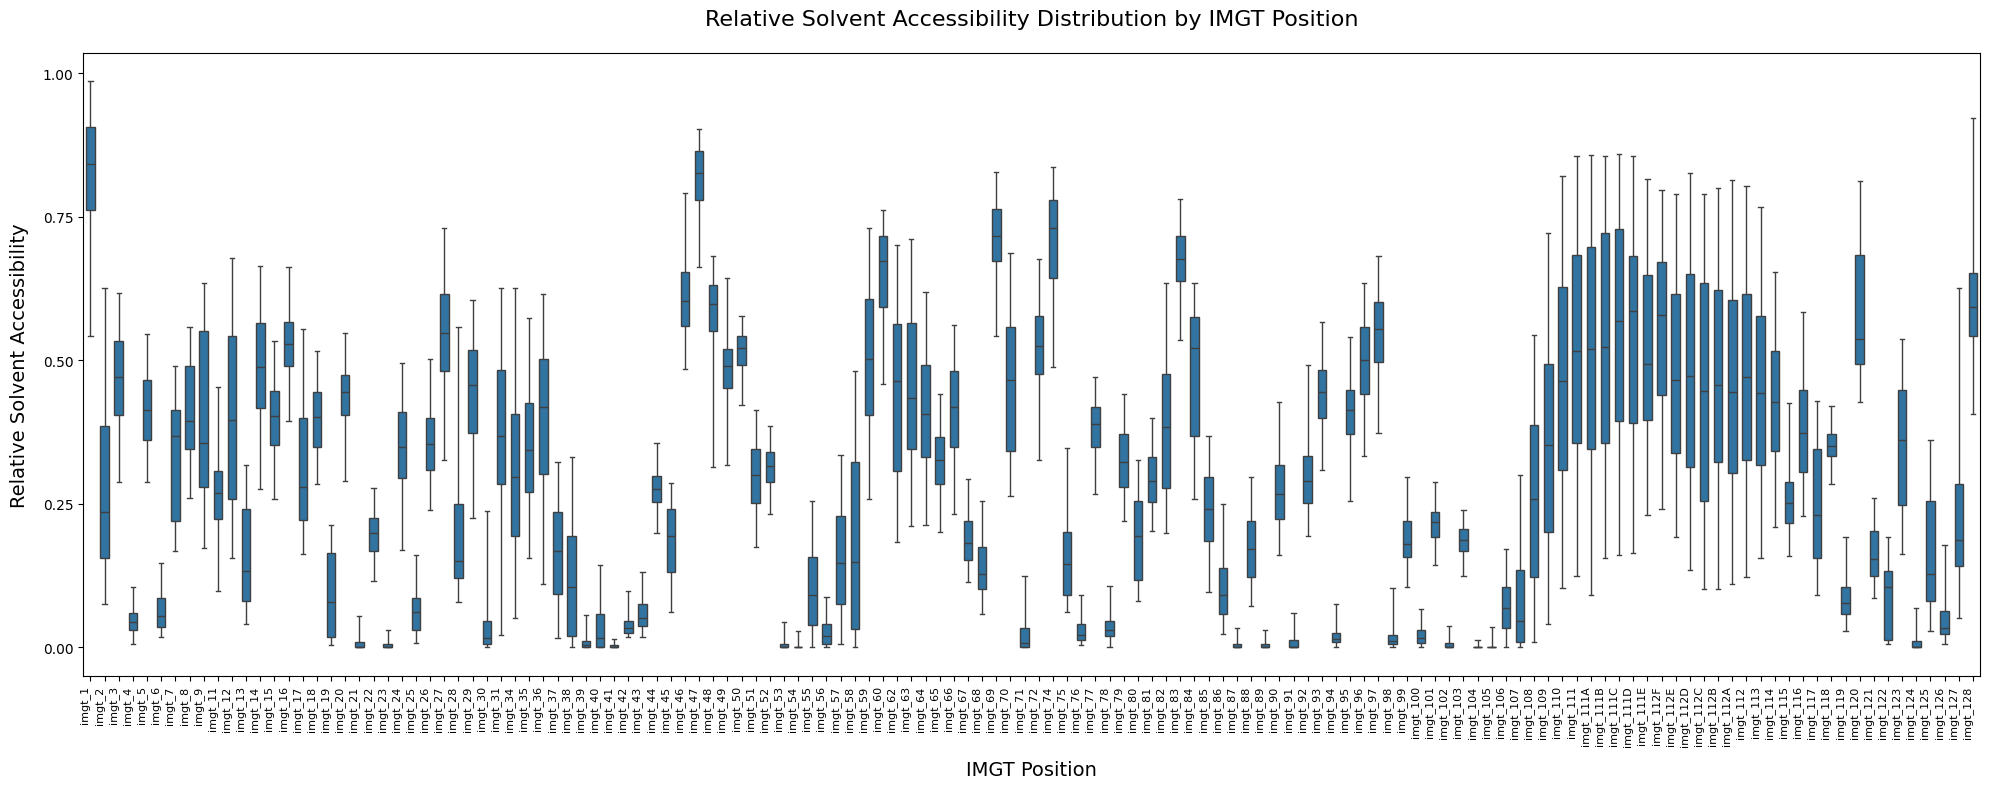

In [2]:



def plot_imgt_solvent_accessibility(df, filter_stat=None, min_percentage=5):
    """
    Create a boxplot of solvent accessibility across IMGT positions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing the IMGT position columns and solvent accessibility data
    filter_stat : str, optional
        Value to filter the 'stat' column by (e.g., 'rel_asa')
    color_palette : str or list, optional
        Color palette to use for the boxplot (default: 'Blues')
        
    Returns:
    --------
    matplotlib.figure.Figure
        The figure object for further customization or saving
    """
    # Apply filter if specified
    if filter_stat is not None and 'stat' in df.columns:
        df = df[df['stat'] == filter_stat]
    
    # Identify all IMGT position columns - handling both formats: imgt_1 or IMGT_1
    imgt_cols = [col for col in df.columns if col.lower().startswith('imgt_')]
    
    if not imgt_cols:
        raise ValueError("No IMGT position columns found in the dataframe")
    
    # Filter IMGT positions that appear in at least min_percentage of antibodies
    total_rows = len(df)
    threshold = total_rows * (min_percentage / 100)
    
    filtered_cols = []
    for col in imgt_cols:
        non_null_count = df[col].count()  # Count non-null values
        if non_null_count >= threshold:
            filtered_cols.append(col)

    
    # Convert from wide to long format for seaborn
    df_long = pd.melt(
        df, 
        value_vars=filtered_cols,
        var_name='imgt_position', 
        value_name='solvent_accessibility'
    )
    df_long['solvent_accessibility'] = df_long['solvent_accessibility'].astype(float)

    # Set up the figure with appropriate size
    plt.figure(figsize=(20, 8))
    
    # Create the boxplot
    ax = sns.boxplot(
        x='imgt_position',
        y='solvent_accessibility',
        data=df_long,
        width=0.6,
        fliersize=3,
        linewidth=1,
        showfliers=False,
        whis=(5,95),  # Adjust whiskers to show 90% range
    )
    
    # Customize the plot
    plt.title('Relative Solvent Accessibility Distribution by IMGT Position', fontsize=16, pad=20)
    plt.xlabel('IMGT Position', fontsize=14, labelpad=10)
    plt.ylabel('Relative Solvent Accessibility', fontsize=14, labelpad=10)
    
    # FIXED: Properly set y-ticks using np.linspace
    # Create 5 evenly spaced ticks between 0 and 1
    y_ticks = np.linspace(0, 1, 5)
    ax.set_yticks(y_ticks)
    #ax.set_yticklabels([f'{y:.1f}' for y in y_ticks])  # Format to show one decimal place
    
    # If there are many IMGT positions, rotate the x-axis labels
    if len(imgt_cols) > 10:
        plt.xticks(rotation=90, ha='right', fontsize=8)
    
    # Ensure tight layout
    plt.tight_layout()
    
    medians = df_long.groupby('imgt_position', sort=False)['solvent_accessibility'].median().reset_index()
    medians['imgt_position'] = medians['imgt_position'].str.replace('imgt_', '', case=False)
    for i,j in enumerate('ABCDEFGHIJ'):
        medians['imgt_position'] = medians['imgt_position'].str.replace(j, '.' + str(i+1), case=False)

    return medians

sa_df = pd.read_csv('/fh/fast/matsen_e/nharel/pdb-db.dnsm_1m-v1jaffe+v1tang-joint.ALL.csv')
sa_df_filtered = sa_df = sa_df[(sa_df['organism'] == 'human_ig') & (sa_df['source'] == 'opig-imgt') & (sa_df.chain_type == 'H') & (sa_df['stat'] == 'rel_asa')]
solvent_accessibilities_median_df = plot_imgt_solvent_accessibility(sa_df_filtered[sa_df_filtered['stat'] == 'rel_asa'])

solvent_accessibilities_median_df['imgt_position'] = solvent_accessibilities_median_df['imgt_position'].astype(float)

In [3]:
sa_df.groupby(['j_family']).size().sort_values().tail(n=20)

j_family
IGHJ1,IGHJ5,IGHJ4,IGHJ6       8
IGHJ8,IGHJ5,IGHJ4,IGHJ3      12
IGHJ2,IGHJ4                  13
IGHJ5,IGHJ4,IGHJ8            15
IGHJ6,IGHJ3                  21
IGHJ1,IGHJ4                  26
IGHJ4,IGHJ3                  26
IGHJ1,IGHJ5                  38
IGHJ2,IGHJ5,IGHJ4            39
IGHJ4,IGHJ6                  44
IGHJ1,IGHJ5,IGHJ4            66
IGHJ5,IGHJ4                  68
IGHJ1,IGHJ5,IGHJ4,IGHJ3      75
IGHJ2                       178
IGHJ5                       281
IGHJ1                       339
IGHJ3                       414
IGHJ6                       553
IGHJ4                       885
unknown                    3254
dtype: int64

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home

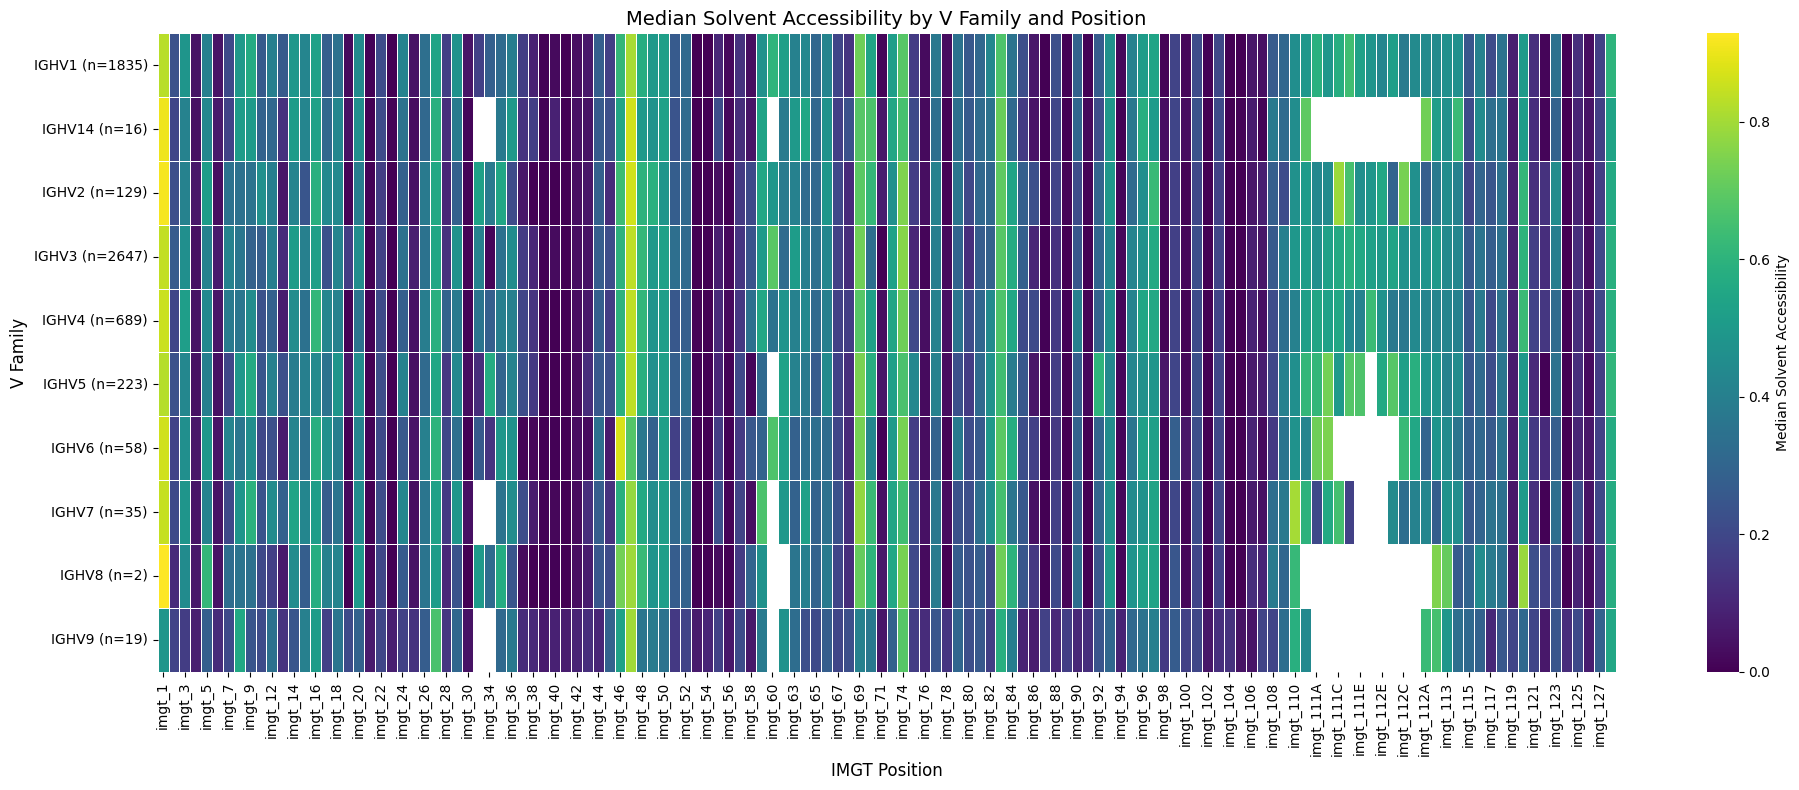

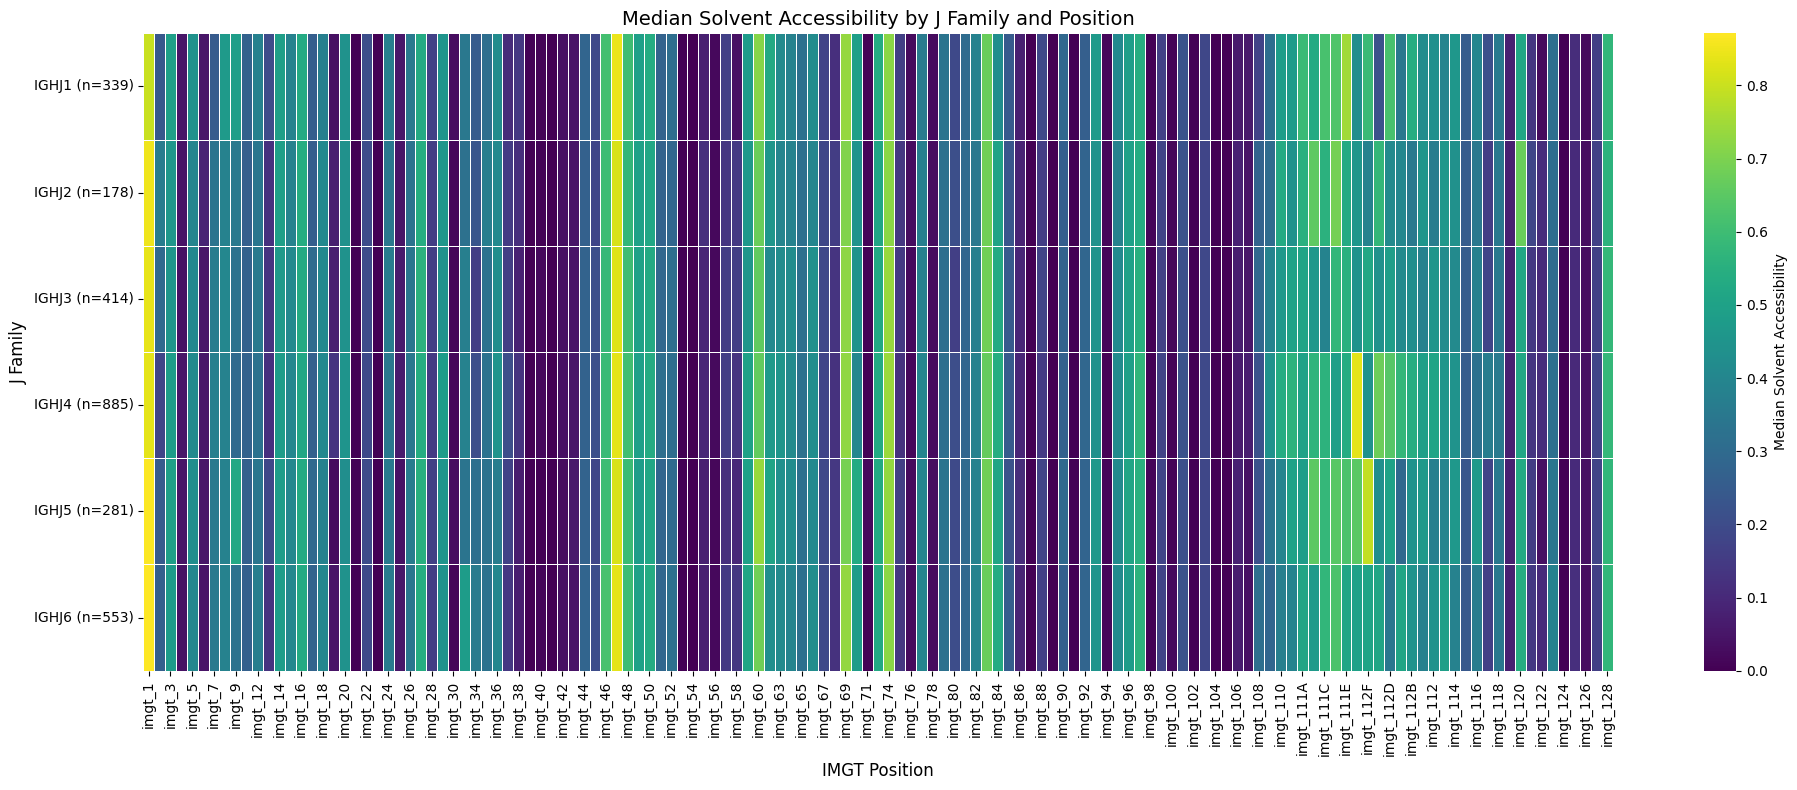

In [4]:
def create_solvent_accessibility_heatmap(df, position_cols, family_col, value_col='solvent_accessibility', 
                                         figsize=(20, 8), cmap='viridis', title=None, min_percentage=5):
    """
    Creates a heatmap of median solvent accessibility values for different positions across gene families.
    Keeps the original order of position columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing IMGT positions and gene family data
    position_cols : list
        List of column names representing IMGT positions (e.g., 'imgt_1', 'imgt_2', etc.)
    family_col : str
        Column name for the gene family (e.g., 'v_family' or 'j_family')
    value_col : str, optional
        Column name containing the solvent accessibility values, default: 'solvent_accessibility'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 8)
    cmap : str, optional
        Colormap for heatmap, default: 'viridis'
    title : str or None, optional
        Plot title, default: None (auto-generated)
    min_percentage : float, optional
        Minimum percentage of non-null values required for a position column to be included, default: 5
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Make a copy of the DataFrame to avoid modifications to the original
    df = df.copy()

    # filter out rows with ',' in the family column
    df = df[~df[family_col].str.contains(',')]
    df = df[~df[family_col].str.contains('unknown')]
    
    # Filter IMGT positions that appear in at least min_percentage of antibodies
    total_rows = len(df)
    threshold = total_rows * (min_percentage / 100)
    filtered_position_cols = []
    for col in position_cols:
        non_null_count = df[col].count()  # Count non-null values
        if non_null_count >= threshold:
            filtered_position_cols.append(col)
    
    # Use the filtered position columns
    position_cols = filtered_position_cols
    
    # Convert string columns to numeric
    for col in position_cols:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Reshape the data for the heatmap
    result_data = []
    
    # Get unique families
    families = df[family_col].unique()
    
    # For each position column, calculate median value per family
    for pos_col in position_cols:
        pos_name = pos_col  # Extract just the position name/number
        
        for family in families:
            # Filter data for this family
            family_data = df[df[family_col] == family]
            
            # Calculate median value for this position and family
            median_value = family_data[pos_col].median()
            
            # Add to result data
            result_data.append({
                'Position': pos_name,
                'Family': family,
                'Median_Value': median_value
            })
    
    # Create a dataframe from the results
    result_df = pd.DataFrame(result_data)
    
    # Pivot the data for the heatmap
    pivot_df = result_df.pivot(index='Family', columns='Position', values='Median_Value')
    
    # Reorder columns to maintain original order from position_cols
    # This is the key change to preserve the original column order
    pivot_df = pivot_df.reindex(columns=position_cols)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the heatmap
    sns.heatmap(pivot_df, cmap=cmap, ax=ax, 
                cbar_kws={'label': f'Median {value_col.replace("_", " ").title()}'},
                linewidths=0.5)
    
    # Generate title if not provided
    if title is None:
        title = f'Median {value_col.replace("_", " ").title()} by {family_col.replace("_", " ").title()} and Position'
    
    # Add labels and title
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('IMGT Position', fontsize=12)
    ax.set_ylabel(family_col.replace('_', ' ').title(), fontsize=12)
    
    # Calculate the number of families analyzed
    family_counts = df[family_col].value_counts()
    
    # Modify the y-tick labels to include the count of samples per family
    ylabels = [f"{family} (n={family_counts[family]})" for family in pivot_df.index]
    ax.set_yticklabels(ylabels, rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

# Assuming df is your dataframe and contains columns like 'imgt_1', 'imgt_2', etc., 'v_family', and 'solvent_accessibility'
position_cols = [col for col in sa_df_filtered.columns if col.startswith('imgt_')]

# # For V families
fig_v, ax_v = create_solvent_accessibility_heatmap(sa_df_filtered, position_cols, 'v_family')

# # For J families
fig_j, ax_j = create_solvent_accessibility_heatmap(sa_df_filtered, position_cols, 'j_family')

## Prep data - Rodriguez dataset

In [5]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


Loading /home/nharel/data/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', 440)]
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Using ThriftyHumV0.2-59 for neutral model on device None


Evaluating model: 100%|██████████| 2168/2168 [00:04<00:00, 482.76it/s]


Loading model
Loading branch lengths


Calculating model predictions: 100%|██████████| 22/22 [02:37<00:00,  7.16s/it]


Preparing heavy chain plot data
ANARCI seq length mismatch! sample-igg-SC-13 2013
ANARCI seq length mismatch! sample-igg-SC-15 925
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
ANARCI seq length mismatch! sample-igg-SC-19 1803
IMGT mismatch with CDR annotation! sample-igg-W-25 4
IMGT mismatch with CDR annotation! sample-igg-W-19 41
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
IMGT mismatch with CDR annotation! sample-igg-W-37 1
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...


/tmp/ipykernel_12426/2101323801.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete_plotter.site_sub_probs_df[colname] = complete_plotter.site_sub_probs_df[colname].apply(lambda it: it.item())


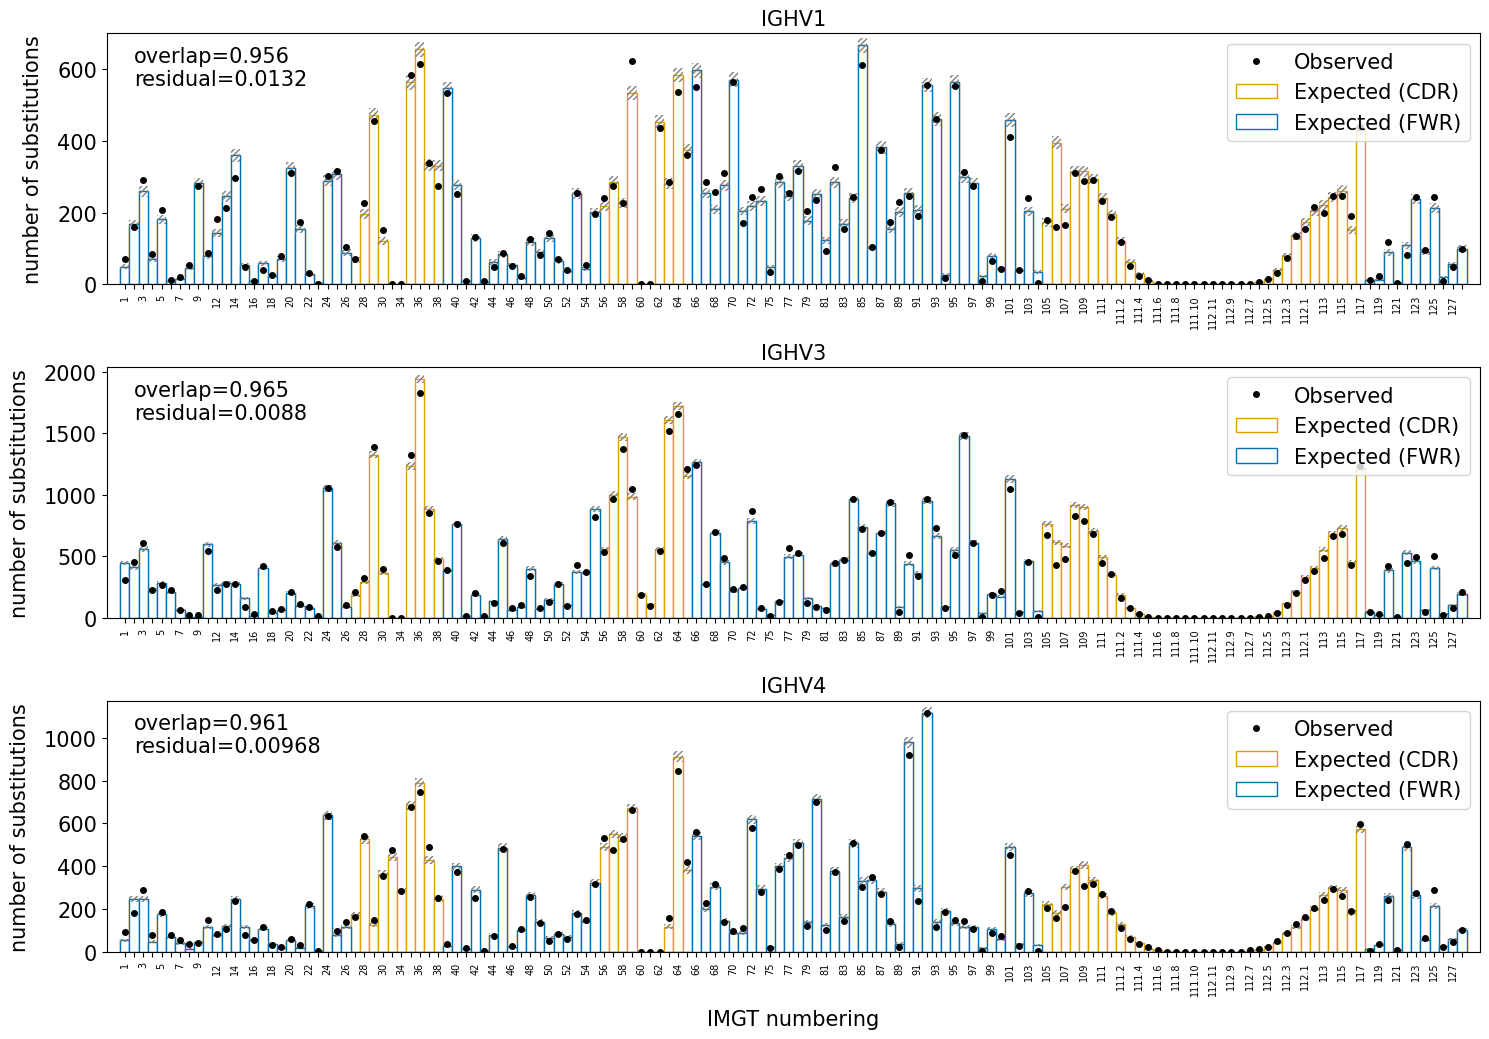

In [5]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["h"]




    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df


    for colname in ["neutral_prob", "selection_factor", "prob"]:
        complete_plotter.site_sub_probs_df[colname] = complete_plotter.site_sub_probs_df[colname].apply(lambda it: it.item())



    ## add j gene annotations to the pcp df
    rodriguez_j_df = load_pcp_df('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz')
    complete_plotter.pcp_df = pd.merge(complete_plotter.pcp_df, rodriguez_j_df.rename(columns={'parent_h':'parent', 'child_h':'child'})[['orig_pcp_idx', 'parent', 'child', 'j_gene', 'v_gene_h']], on=['orig_pcp_idx', 'parent', 'child'], how='left')
    complete_plotter.pcp_df['j_family'] = complete_plotter.pcp_df['j_gene'].str.split('*').str[0]

    pcp_df_for_merge = complete_plotter.pcp_df.copy()
    pcp_df_for_merge = pcp_df_for_merge[['v_gene_h', 'j_gene', 'v_family', 'j_family', 'family']]
    pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index
    site_sub_probs_df = pd.merge(complete_plotter.site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

    ## save for later use
    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)

## Analysis

In [6]:
site_sub_probs_df

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa,v_gene_h,j_gene,v_family,j_family,family
0,0.117029,0.078600,0.009198,False,0,1,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,1401
1,0.132540,0.216011,0.028630,True,0,2,False,GTG,V,ATC,I,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,1401
2,0.264217,0.300616,0.079428,False,0,3,False,CAG,Q,CAA,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,1401
3,0.168813,0.095324,0.016092,False,0,4,False,CTG,L,CTG,L,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,1401
4,0.166957,0.234468,0.039146,False,0,5,False,GTG,V,GTC,V,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,1401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.005085,0.119142,0.000606,False,21751,124,False,GTC,V,GTC,V,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,44
2646367,0.009812,0.617619,0.006060,False,21751,125,False,ACC,T,ACC,T,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,44
2646368,0.005641,0.081594,0.000460,False,21751,126,False,GTC,V,GTC,V,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,44
2646369,0.003799,0.363695,0.001382,False,21751,127,False,TCC,S,TCC,S,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,44


In [7]:
## validate analysis with DNSM plot - makes sense

temp_df = site_sub_probs_df[site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4'])]
temp_df = temp_df.groupby(['v_family', 'site']).selection_factor.mean().reset_index().pivot(index='site', columns='v_family', values='selection_factor')
temp_df['mean_selection_diff'] = temp_df['IGHV3'] - temp_df['IGHV4']
temp_df

v_family,IGHV3,IGHV4,mean_selection_diff
site,,,
1,0.660416,0.152905,0.507511
100,0.263774,0.224036,0.039738
101,0.941043,0.866979,0.074064
102,0.030684,0.044074,-0.013390
103,0.267242,0.298164,-0.030922
...,...,...,...
95,0.810625,0.417241,0.393384
96,1.174174,0.378926,0.795248
97,0.719341,0.423324,0.296017


<Axes: xlabel='site', ylabel='selection_factor'>

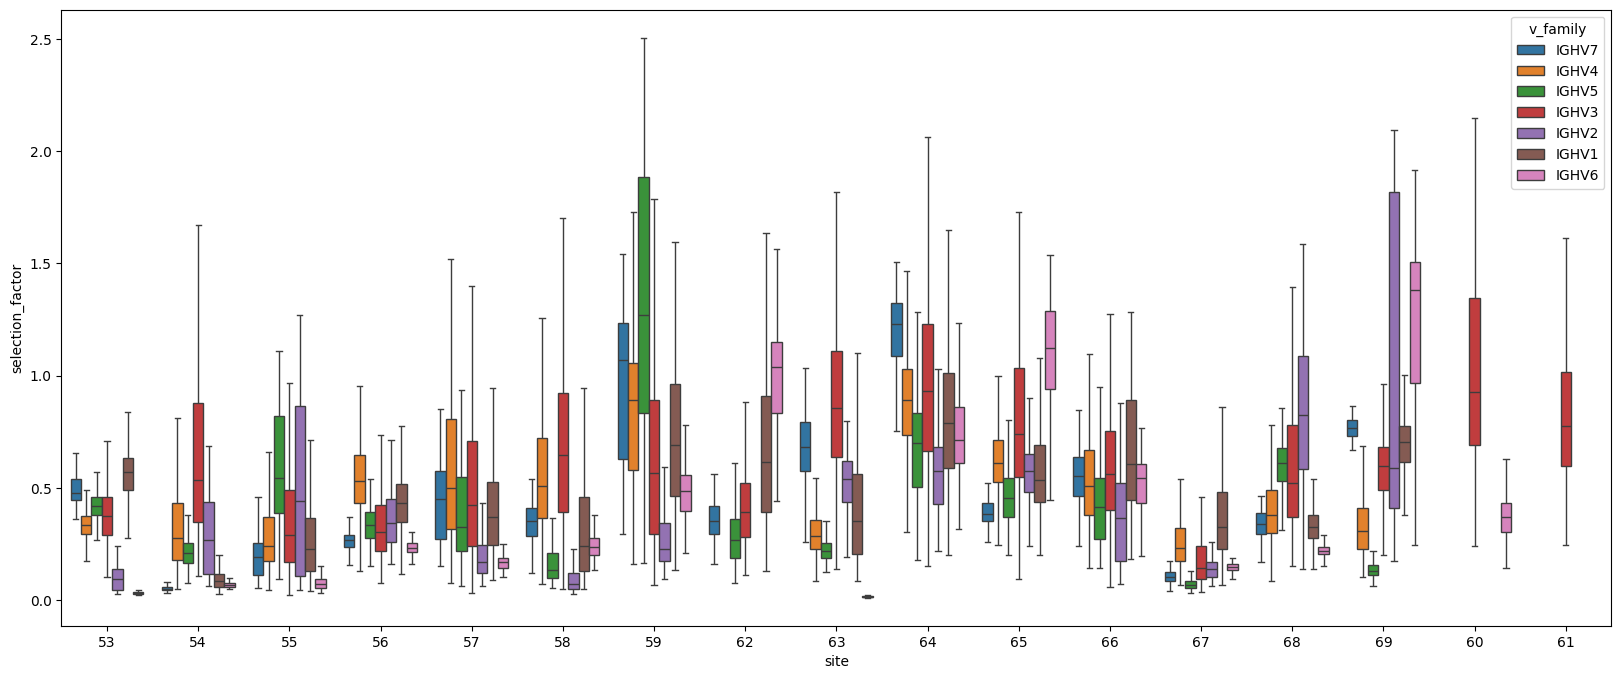

In [8]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.boxplot(data=site_sub_probs_df[(site_sub_probs_df.site.isin([str(i) for i in list(range(53,70))]))], x='site', y='selection_factor', hue='v_family', showfliers=False, ax=ax)



In [9]:
def plot_selection_factor_heatmap(data, family_column='v_family', statistic='mean',
                                 figsize=(20, 4), cmap="coolwarm", linewidths=0.5,
                                 title=None, xlabel='Site', ylabel=None, min_pct=0.05):
    """
    Creates a heatmap of selection factors for different immunoglobulin gene families across sites.
    Filters out positions that appear in less than the specified percentage of pcp_index per family.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing selection factor data
    family_column : str, optional
        Column to use for family grouping ('v_family' or 'j_family'), default: 'v_family'
    statistic : str, optional
        Statistic to plot ('mean' or 'median'), default: 'mean'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 4)
    cmap : str, optional
        Colormap for heatmap, default: "coolwarm"
    linewidths : float, optional
        Width of cell borders, default: 0.5
    title : str or None, optional
        Plot title, default: None (auto-generated)
    xlabel : str, optional
        X-axis label, default: 'Site'
    ylabel : str or None, optional
        Y-axis label, default: None (auto-generated)
    min_pct : float, optional
        Minimum percentage of pcp_index per family for a position to be included, default: 0.05
        
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    if statistic not in ['mean', 'median']:
        raise ValueError("statistic must be either 'mean' or 'median'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    # Convert 'site' to categorical data type with the original order
    site_order = df['site'].unique()  # Get unique sites in their original order
    df['site'] = pd.Categorical(df['site'], categories=site_order, ordered=True)
    
    # Calculate the number of unique pcp_index per family
    family_pcp_counts = df.groupby(family_column)['pcp_index'].nunique()
    family_clonal_families_count = df.groupby(family_column)['family'].nunique()
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate the selected statistic for each family and site
    if statistic == 'mean':
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].mean().reset_index()
        cbar_label = 'Mean Selection Factor'
    else:  # median
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].median().reset_index()
        cbar_label = 'Median Selection Factor'
    
    # Pivot the data to create a matrix suitable for heatmap
    pivot_data = heatmap_data.pivot(index=family_column, columns='site', values='selection_factor')
    
    # Calculate variability (standard deviation) between families for each position
    position_variability = pivot_data.std()
    
    # Get the 5 positions with the highest variability
    top_variable_positions = position_variability.nlargest(5).index.tolist()
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add extra space at the top of the figure for the title and asterisks
    plt.subplots_adjust(top=0.85, bottom=0.25)  # Added bottom margin for x labels
    
    # Create the heatmap
    heatmap = sns.heatmap(pivot_data,
                cmap=cmap,
                center=1,           # Center the colormap at 1
                vmin=0,
                vmax=2,
                linewidths=linewidths,
                cbar_kws={'label': cbar_label},
                ax=ax)
    
    # Generate title if not provided
    if title is None:
        family_type = "V Family" if family_column == 'v_family' else "J Family"
        title = f'{statistic.capitalize()} Selection Factor by {family_type} and Site'
    
    # Generate y-label if not provided
    if ylabel is None:
        ylabel = "V Family" if family_column == 'v_family' else "J Family"
    
    # Add labels and title
    ax.set_title(title, fontsize=14, pad=20)  # Reduced title font size
    ax.set_xlabel(xlabel, fontsize=14)        # Reduced x-label font size
    ax.set_ylabel(ylabel, fontsize=14)        # Reduced y-label font size
    
    # Show all tick labels on y-axis with smaller font size
    ax.tick_params(axis='y', which='major', labelsize=8)
    
    # Modify the y-tick labels to include the count of pcp_index per family
    ylabels = [f"{family} (n={family_pcp_counts[family]}, clonal_families={family_clonal_families_count[family]})" for family in pivot_data.index]
    ax.set_yticklabels(ylabels, rotation=0, fontsize=9)  # Reduced font size for y-tick labels
    
    # Make sure all y-ticks are shown 
    ax.set_yticks(np.arange(len(pivot_data.index)) + 0.5)
    
    # Show all x-tick labels and make font smaller
    ax.tick_params(axis='x', labelsize=7, labelrotation=90)  # Rotate x labels 90 degrees for better fit
    
    # Make sure all x-ticks are shown
    ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.5)
    ax.set_xticklabels(pivot_data.columns, fontsize=8, rotation=90)
    
    # Highlight the 5 positions with the most variability
    for i, position in enumerate(top_variable_positions):
        # Find the column index of this position
        col_idx = list(pivot_data.columns).index(position)
        
        # Add an asterisk to the top of the column, higher up to avoid overlap
        ax.text(
            col_idx + 0.5,  # x position (middle of column)
            -0,  # y position (at the bottom)
            '*',
            ha='center',
            va='center',
            fontsize=12,  # Slightly reduced asterisk size
            color='black'
        )
    
    # Add a legend for the asterisks
    if top_variable_positions:
        ax.text(
            1.02,  # x position (just outside the right edge)
            -0.3,  # y position (below the plot)
            "* Positions with highest variability between families",
            ha='right',
            va='center',
            fontsize=8,  # Reduced legend font size
            transform=ax.transAxes
        )
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

def plot_mutation_heatmap(data, family_column='v_family', statistic='mutation',
                                 figsize=(20, 4), cmap="coolwarm", linewidths=0.5,
                                 title=None, xlabel='Site', ylabel=None, min_pct=0.05):
    """
    Creates a heatmap of selection factors for different immunoglobulin gene families across sites.
    Filters out positions that appear in less than the specified percentage of pcp_index per family.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing selection factor data
    family_column : str, optional
        Column to use for family grouping ('v_family' or 'j_family'), default: 'v_family'
    statistic : str, optional
        Statistic to plot ('mean' or 'median'), default: 'mean'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 4)
    cmap : str, optional
        Colormap for heatmap, default: "coolwarm"
    linewidths : float, optional
        Width of cell borders, default: 0.5
    title : str or None, optional
        Plot title, default: None (auto-generated)
    xlabel : str, optional
        X-axis label, default: 'Site'
    ylabel : str or None, optional
        Y-axis label, default: None (auto-generated)
    min_pct : float, optional
        Minimum percentage of pcp_index per family for a position to be included, default: 0.05
        
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    # Convert 'site' to categorical data type with the original order
    site_order = df['site'].unique()  # Get unique sites in their original order
    df['site'] = pd.Categorical(df['site'], categories=site_order, ordered=True)
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate the selected statistic for each family and site
    heatmap_data = filtered_df.groupby([family_column, 'site'])['mutation'].mean().reset_index()
    cbar_label = 'Mutation frequency'
    
    # Pivot the data to create a matrix suitable for heatmap
    pivot_data = heatmap_data.pivot(index=family_column, columns='site', values='mutation')
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the heatmap
    sns.heatmap(pivot_data,
                cmap=cmap,
                linewidths=linewidths,
                cbar_kws={'label': cbar_label},
                ax=ax)
    
    # Generate title if not provided
    if title is None:
        family_type = "V Family" if family_column == 'v_family' else "J Family"
        title = f'{statistic.capitalize()} Observed Mutation Frequency by {family_type} and Site'
    
    # Generate y-label if not provided
    if ylabel is None:
        ylabel = "V Family" if family_column == 'v_family' else "J Family"
    
    # Add labels and title
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='y', labelrotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

/tmp/ipykernel_12426/3394520985.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
/tmp/ipykernel_12426/3394520985.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].mean().reset_index()
/tmp/ipykernel_12426/3394520985.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s

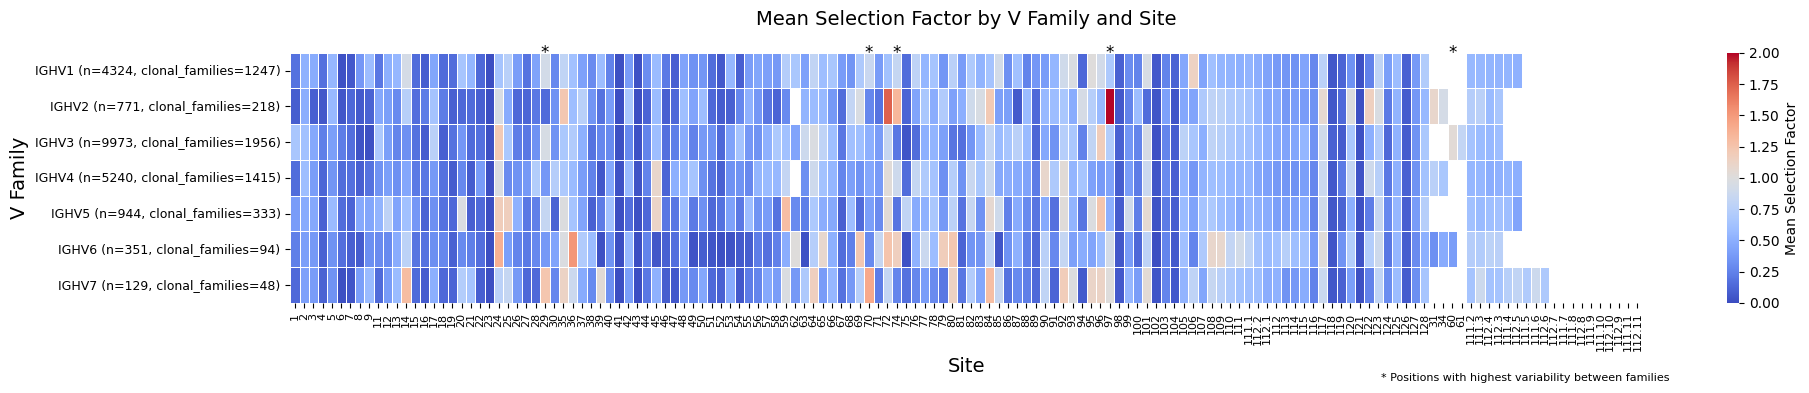

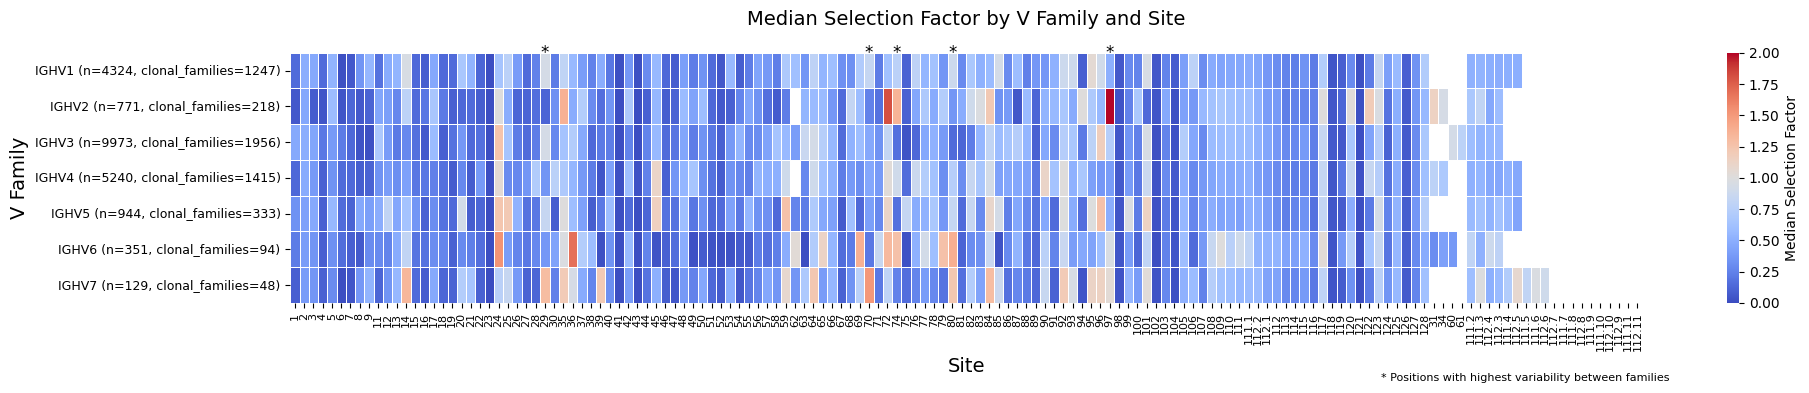

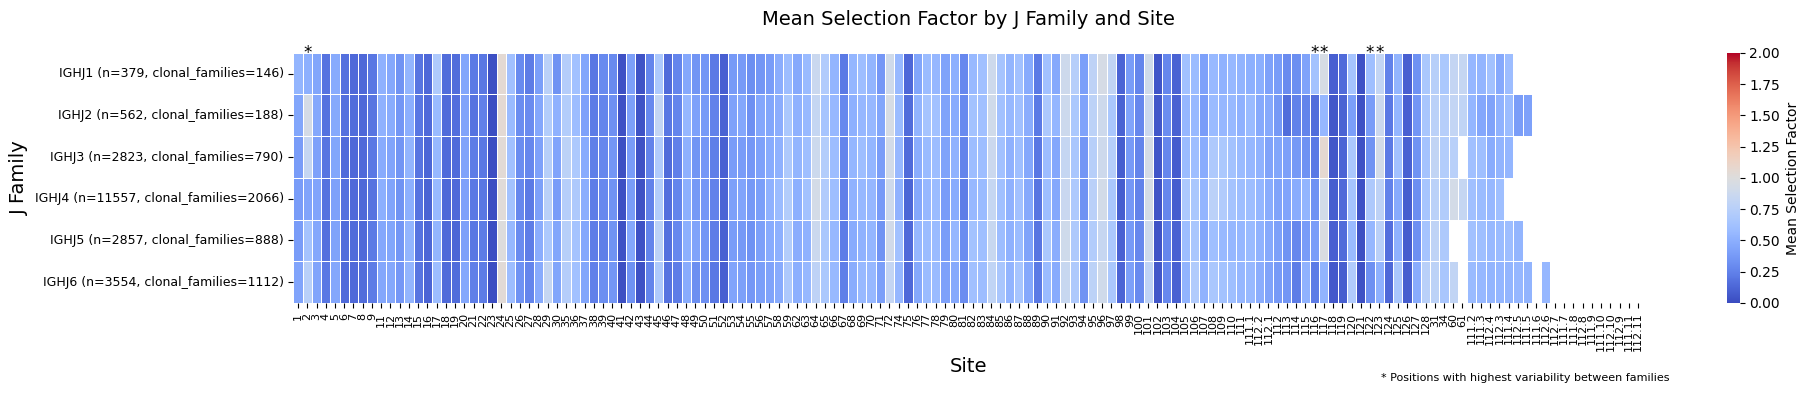

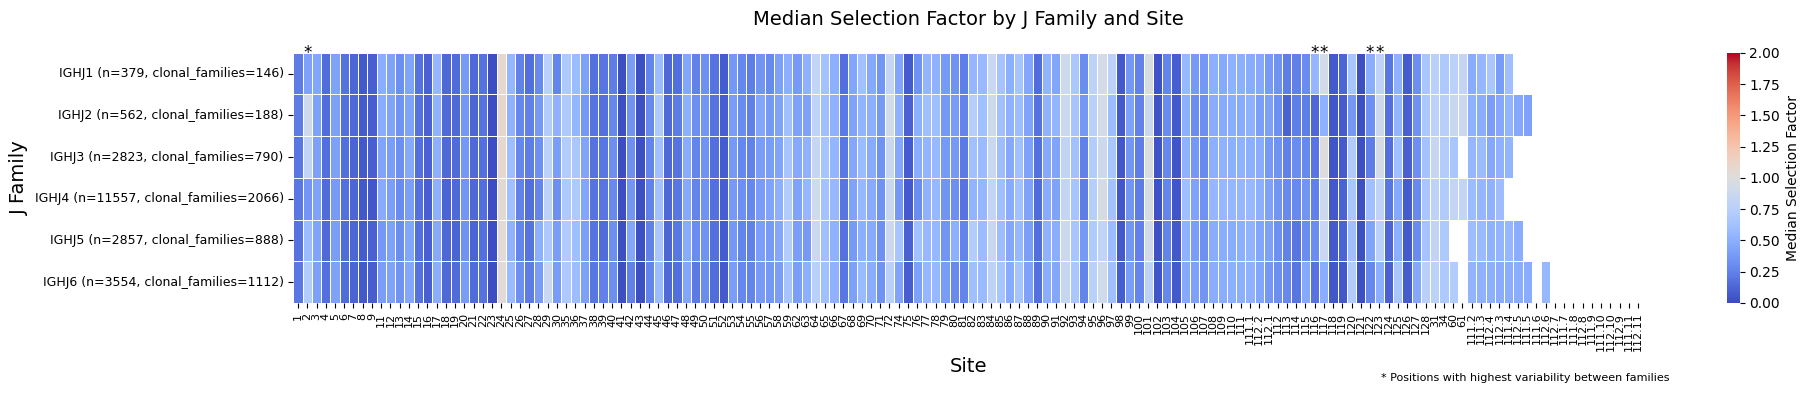

In [10]:
# Plot mean selection factor for V families (default behavior)
fig, ax = plot_selection_factor_heatmap(site_sub_probs_df)

# Plot median selection factor for V families
fig, ax = plot_selection_factor_heatmap(site_sub_probs_df, statistic='median')

# Plot mutation count for V families
#fig, ax = plot_mutation_heatmap(site_sub_probs_df)

# Plot mean selection factor for J families
fig, ax = plot_selection_factor_heatmap(site_sub_probs_df, family_column='j_family')

# Plot mean selection factor for J families
fig, ax = plot_selection_factor_heatmap(site_sub_probs_df, family_column='j_family', statistic='median')

# Plot mutation count for V families
#fig, ax = plot_mutation_heatmap(site_sub_probs_df, family_column='j_family')


- V families have a lot of differences between them, but J families are more similar in terms of selection factors.
- For different V genes, we see selection changes in the J gene area as well - for example positions 117,120,122
- For different J genes, we do not see a lot of effect at this level for the antibody area that arised from the V gene. We do see some effect for sites 2,28-30, 80 (just by eye)
- Could the changes be just because different V and J genes are more commonly seen together (for example, when we have J3 we usually get V2, and this is why it looks like a change in selection factor for position 2), or is this also true if we look at J gene families all having the same V gene?

/tmp/ipykernel_7741/3394520985.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
/tmp/ipykernel_7741/3394520985.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].median().reset_index()
/tmp/ipykernel_7741/3394520985.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  si

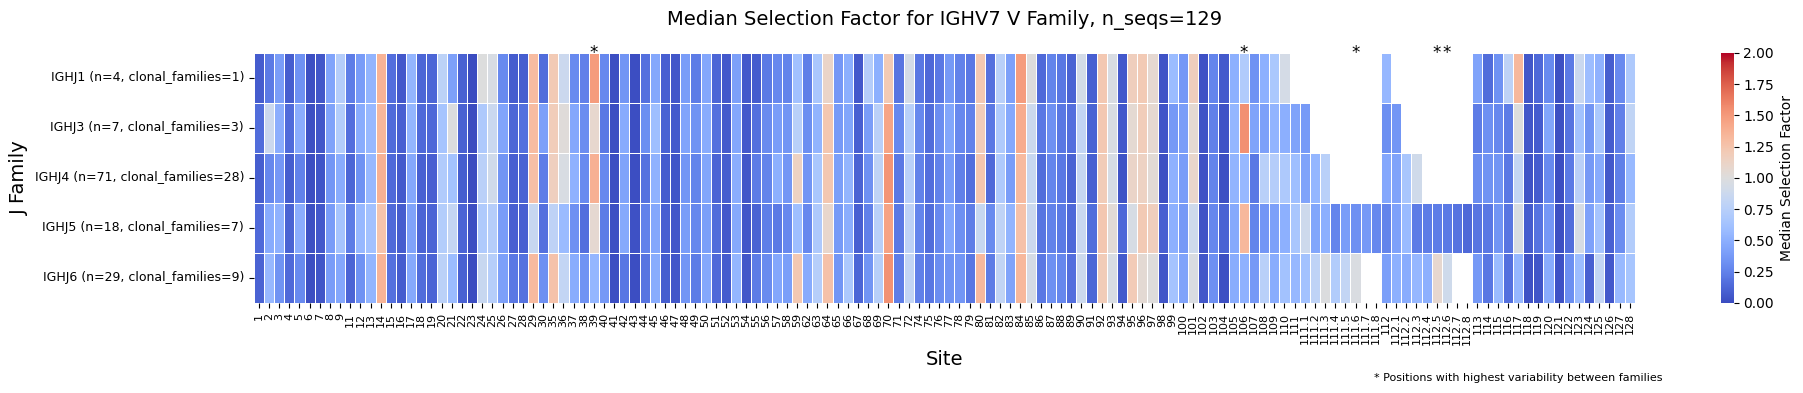

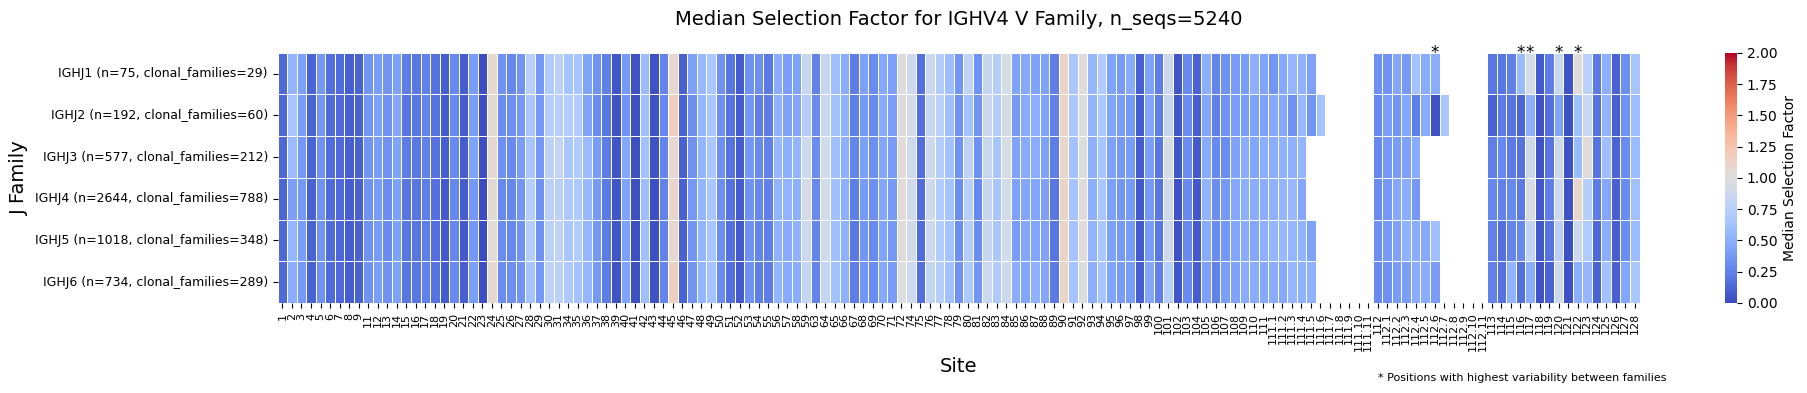

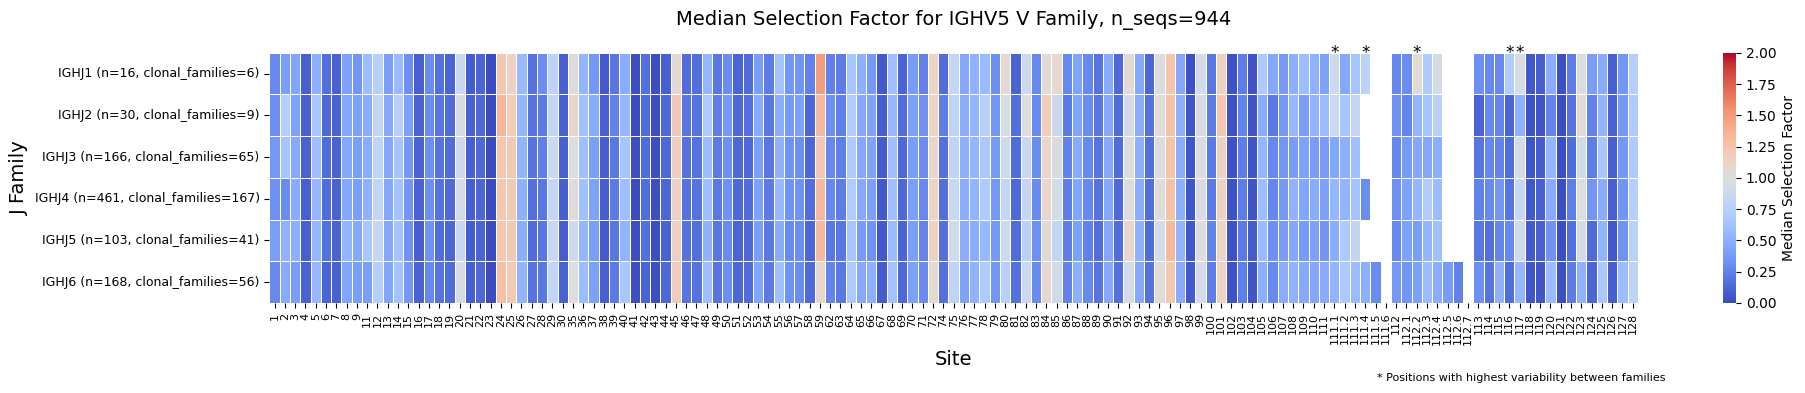

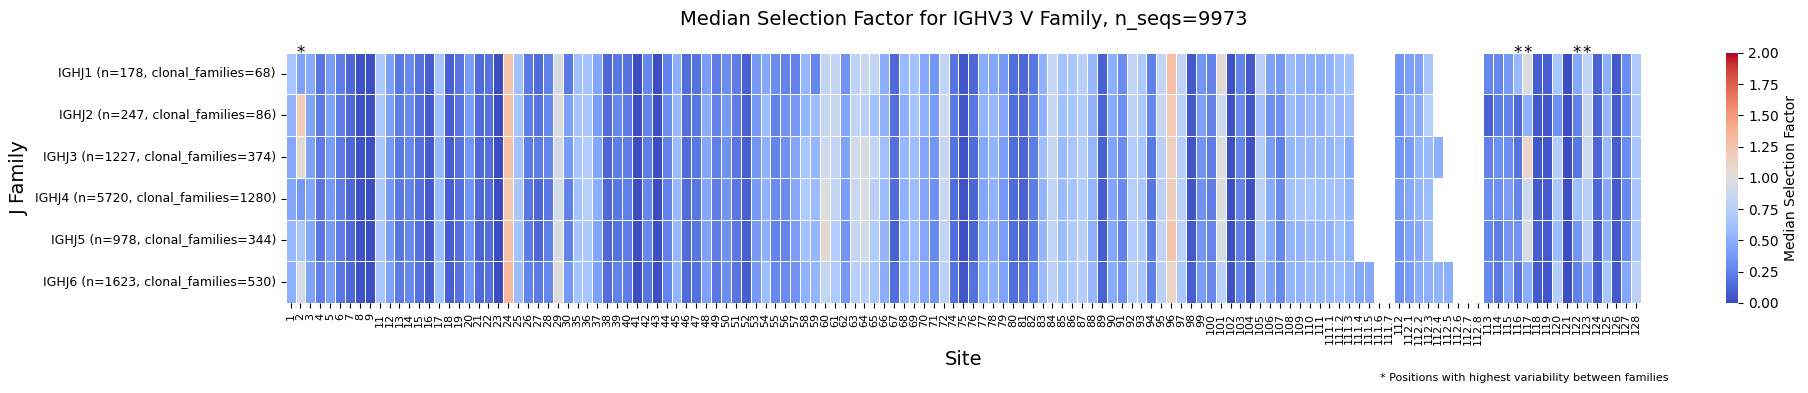

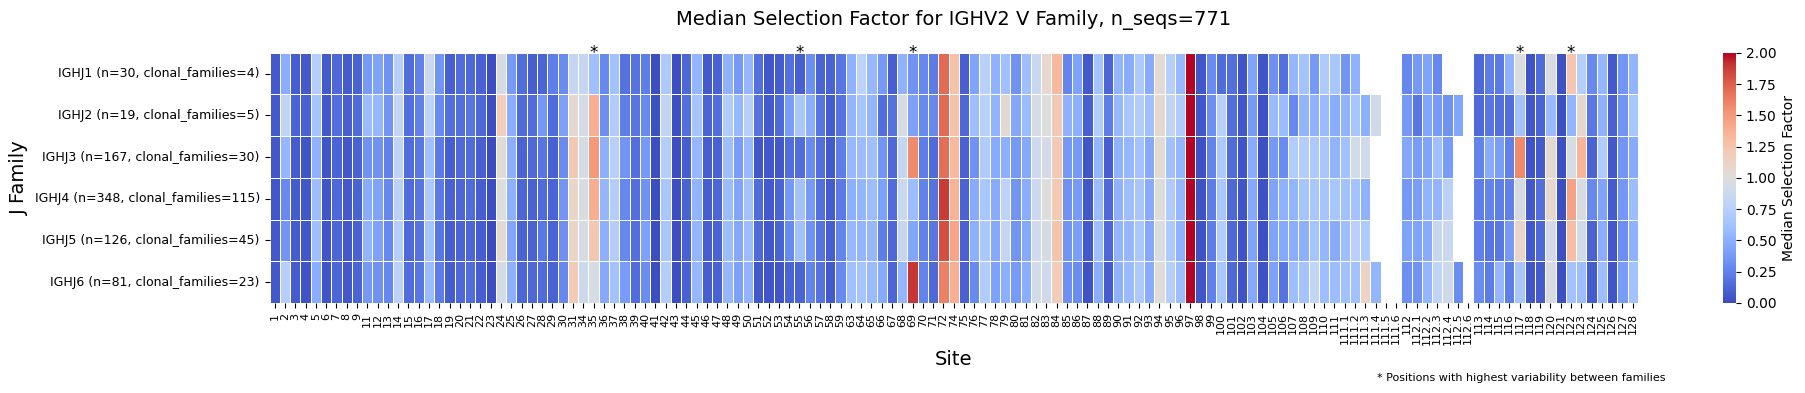

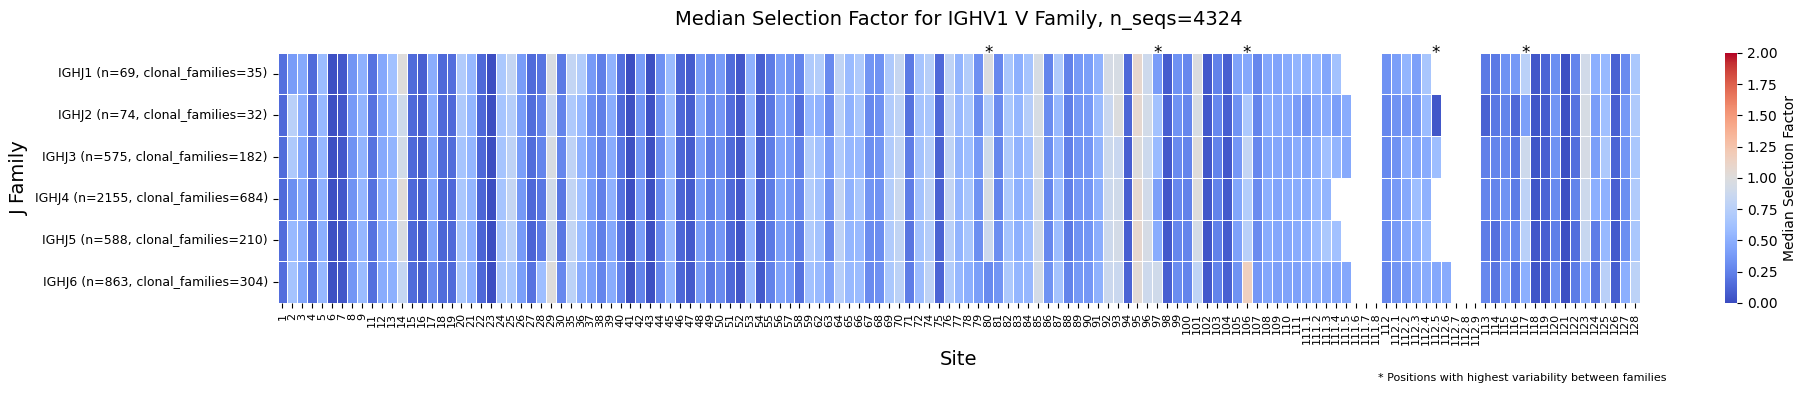

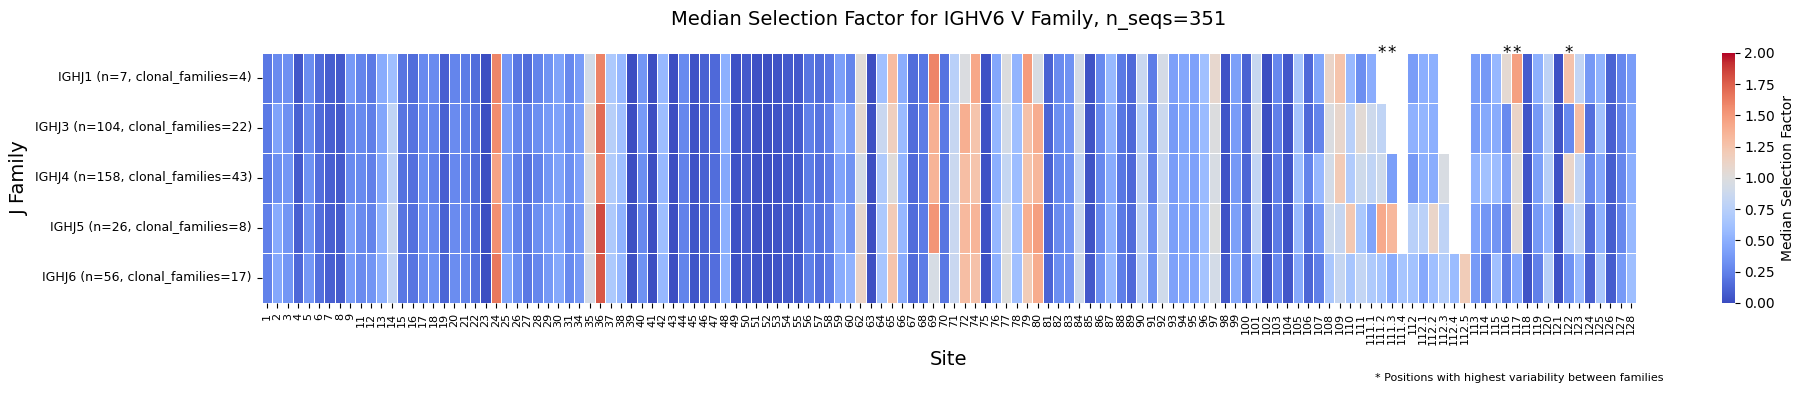

In [113]:
# Plot mean selection factor for J families, per constant V family
for v_family in site_sub_probs_df['v_family'].unique():
    cur_df = site_sub_probs_df[site_sub_probs_df.v_family == v_family]
    fig, ax = plot_selection_factor_heatmap(cur_df, family_column='j_family', title=f"Median Selection Factor for {v_family} V Family, n_seqs={cur_df['pcp_index'].nunique()}", statistic='median')


/tmp/ipykernel_7741/3394520985.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
/tmp/ipykernel_7741/3394520985.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].median().reset_index()
/tmp/ipykernel_7741/3394520985.py:61: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  si

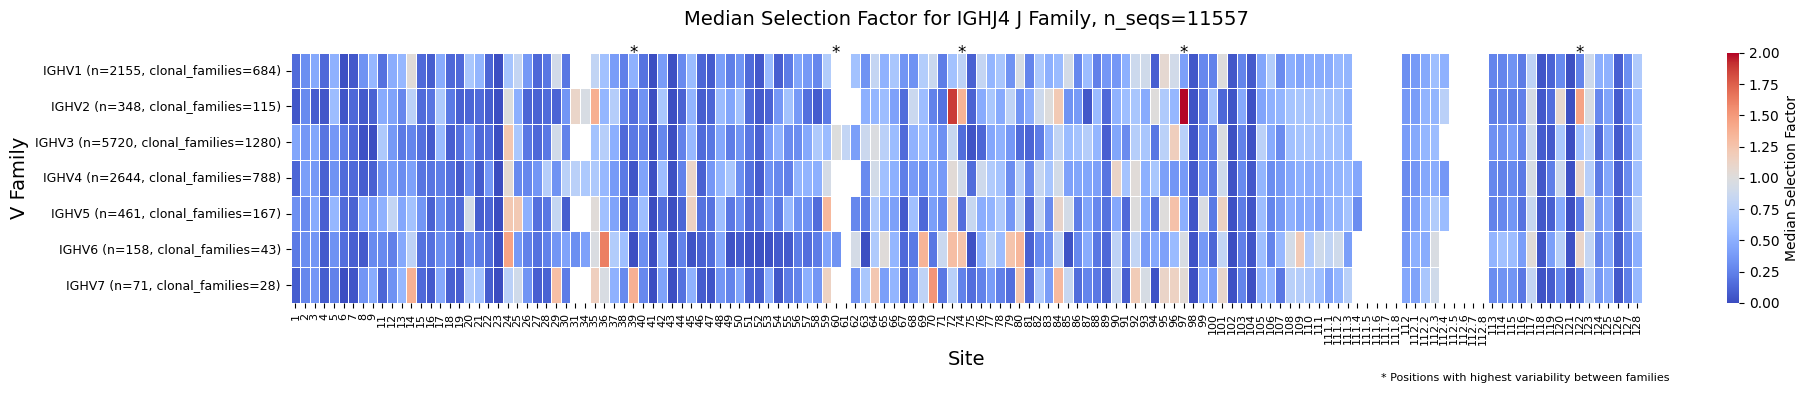

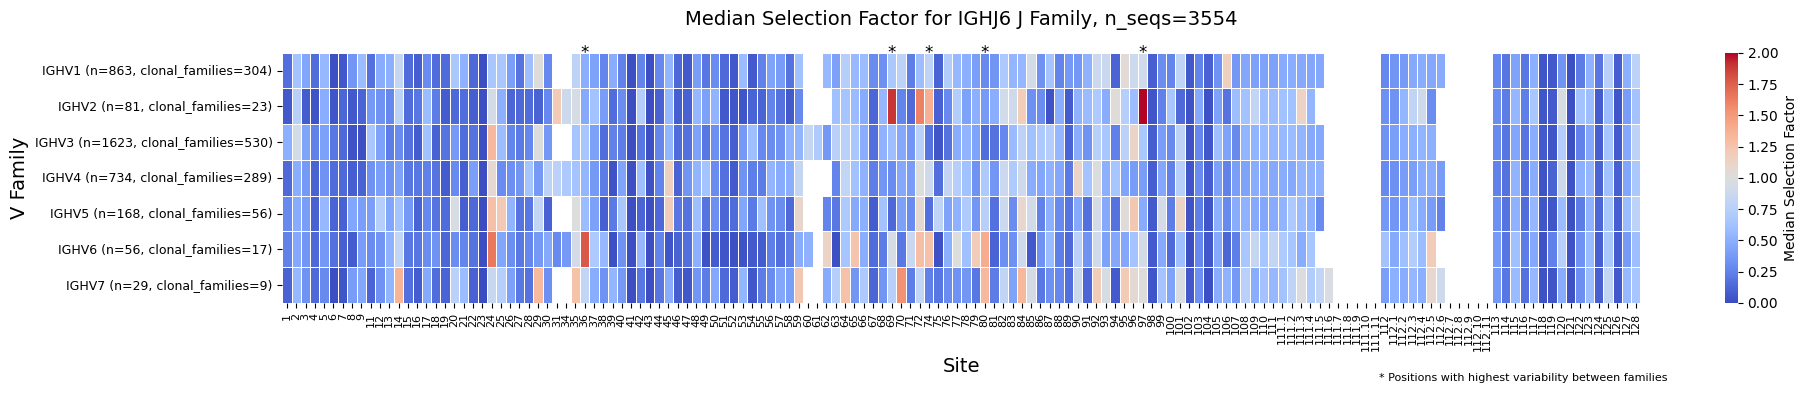

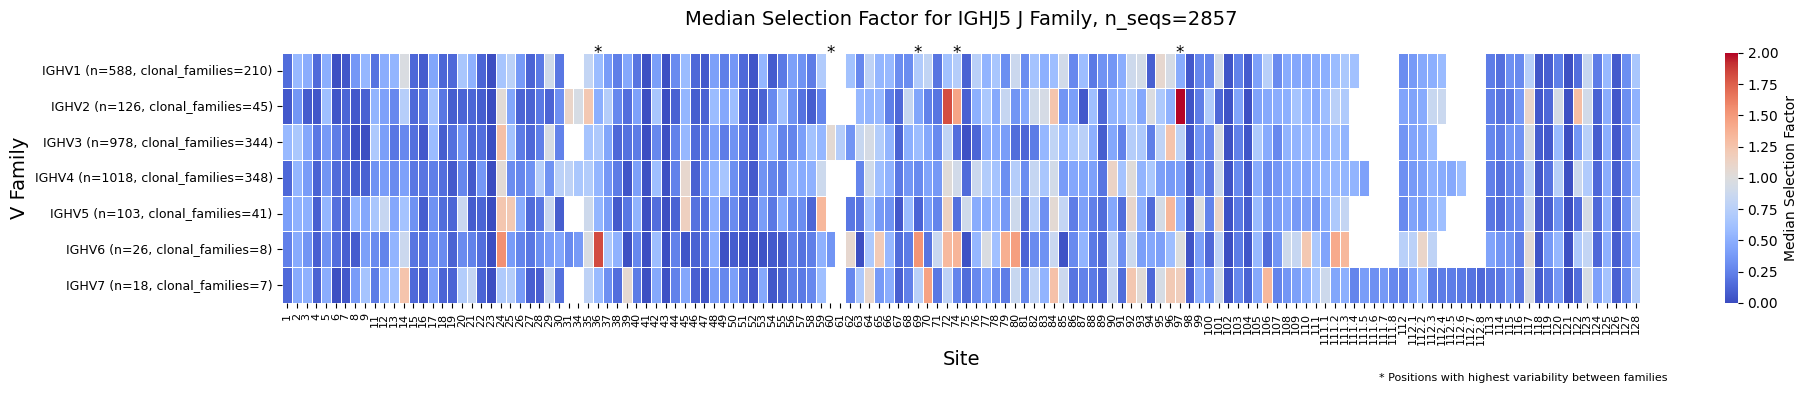

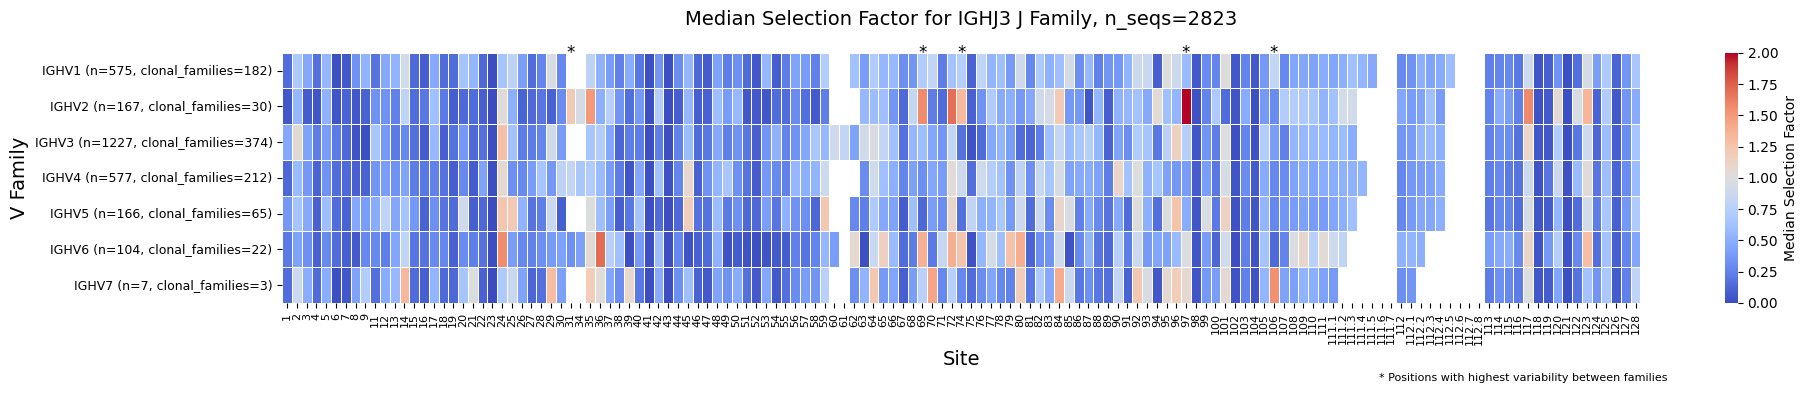

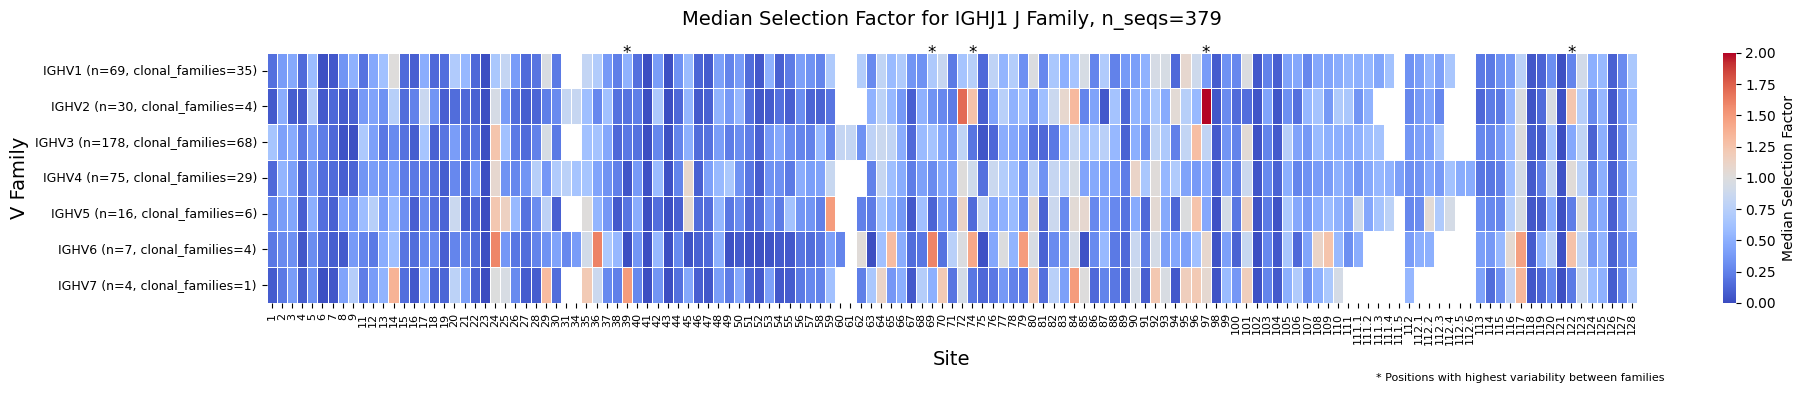

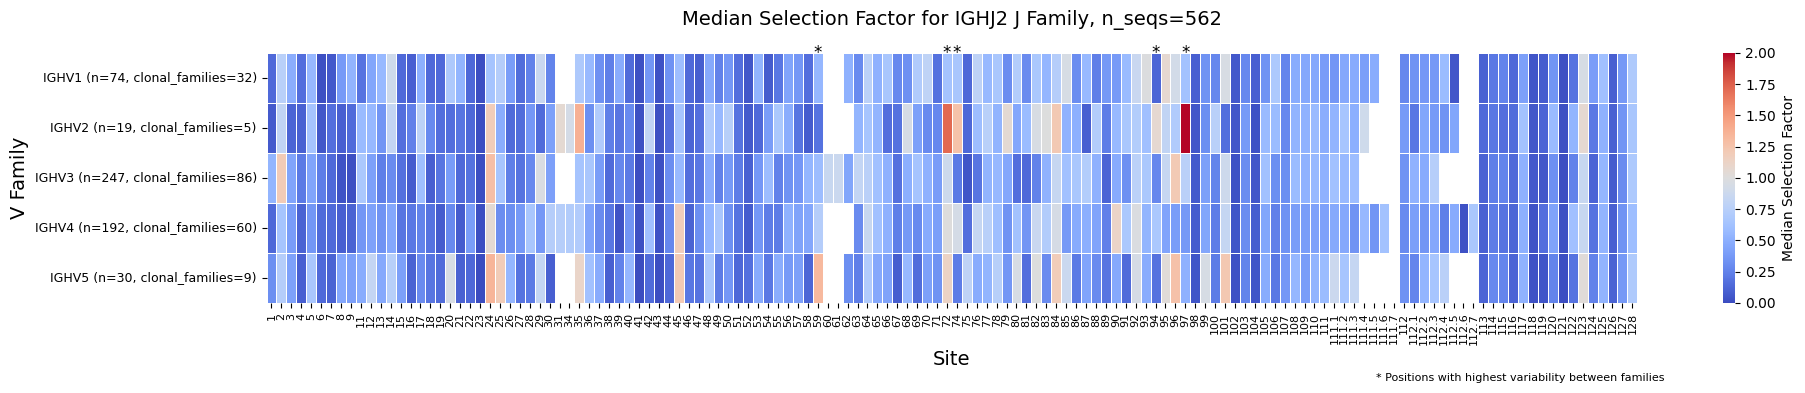

In [114]:
# Plot mean selection factor for V families, per constant J family
for j_family in site_sub_probs_df['j_family'].unique():
    cur_df = site_sub_probs_df[site_sub_probs_df.j_family == j_family]
    fig, ax = plot_selection_factor_heatmap(cur_df, family_column='v_family', title=f"Median Selection Factor for {j_family} J Family, n_seqs={cur_df['pcp_index'].nunique()}", statistic='median')


In [18]:
#create a dataframe of the most common parent aa per site per v family


In [38]:
import pandas as pd

def get_most_common_parent_aa(df, family_column='family', min_pct=0.05):
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])
    
    # Create a list to store results
    results = []
    
    # Group by family and site
    grouped = filtered_df.groupby([family_column, 'site'])
    
    # Iterate through each group
    for (gene_family, site), group in grouped:
        # Count occurrences of parent AAs
        aa_counts = group['parent_aa'].value_counts()
        
        # Get the most common AA
        most_common_aa = aa_counts.index[0]
        
        # Calculate the percentage
        percent = (aa_counts.iloc[0] / len(group)) * 100
        
        # Append to results
        results.append({
            'gene_family': gene_family,
            'site': site,
            'parent_aa': most_common_aa,
            'parent_aa_percent': round(percent, 2)
        })
    
    # Convert to DataFrame
    result_df = pd.DataFrame(results)
    
    # Sort the result DataFrame based on the original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df

def get_most_common_parent_codon(df, family_column='family', min_pct=0.05):
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])
    
    # Create a list to store results
    results = []
    
    # Group by family and site
    grouped = filtered_df.groupby([family_column, 'site'])
    
    # Iterate through each group
    for (gene_family, site), group in grouped:
        # Count occurrences of parent codons
        codon_counts = group['parent_codon'].value_counts()
        
        # Get the most common codon
        most_common_codon = codon_counts.index[0]
        
        # Calculate the percentage
        percent = (codon_counts.iloc[0] / len(group)) * 100
        
        # Append to results
        results.append({
            'gene_family': gene_family,
            'site': site,
            'parent_codon': most_common_codon,
            'parent_codon_percent': round(percent, 2)
        })
    
    # Convert to DataFrame
    result_df = pd.DataFrame(results)
    
    # Sort the result DataFrame based on the original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df

# Example usage
# most_common_aa_df = get_most_common_parent_aa(site_sub_probs_df, family_column='v_family')
# most_common_codon_df = get_most_common_parent_codon(site_sub_probs_df, family_column='v_family')


most_common_aa_df = get_most_common_parent_aa(site_sub_probs_df)
most_common_codon_df = get_most_common_parent_codon(site_sub_probs_df)
print("Most Common Parent AAs:\n", most_common_aa_df)
print("\nMost Common Parent Codons:\n", most_common_codon_df)

KeyboardInterrupt: 

In [ ]:


def get_most_common_parent_aa(df, family_column='family', min_pct=0.05):
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    # Compute total unique pcp_indices per family more efficiently
    family_total_pcp_indices = df.groupby(family_column)['pcp_index'].nunique()
    
    # Compute site pcp_index coverage more efficiently
    # Group by family and site, then count unique pcp_indices
    site_pcp_counts = df.groupby([family_column, 'site'])['pcp_index'].nunique().reset_index()
    
    # Compute percentage of pcp_index coverage
    site_pcp_counts['pcp_percentage'] = site_pcp_counts.apply(
        lambda row: row['pcp_index'] / family_total_pcp_indices[row[family_column]], 
        axis=1
    )
    
    # Filter sites above threshold
    valid_sites = site_pcp_counts[site_pcp_counts['pcp_percentage'] >= min_pct]
    
    # Create a set of valid site-family combinations
    valid_site_family = set(tuple(x) for x in valid_sites[[family_column, 'site']].values)
    
    # Filter the original dataframe more efficiently
    filtered_df = df[df.apply(lambda row: (row[family_column], row['site']) in valid_site_family, axis=1)]
    
    # Compute most common parent AAs
    result_df = filtered_df.groupby([family_column, 'site'])['parent_aa'].agg(
        lambda x: pd.Series([
            x.value_counts().index[0],  # most common AA
            (x.value_counts().iloc[0] / len(x)) * 100  # percentage
        ])
    ).reset_index()
    
    result_df.columns = ['gene_family', 'site', 'parent_aa', 'parent_aa_percent']
    
    # Round the percentage
    result_df['parent_aa_percent'] = result_df['parent_aa_percent'].round(2)
    
    # Sort based on original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df

def get_most_common_parent_codon(df, family_column='family', min_pct=0.05):
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    # Compute total unique pcp_indices per family more efficiently
    family_total_pcp_indices = df.groupby(family_column)['pcp_index'].nunique()
    
    # Compute site pcp_index coverage more efficiently
    # Group by family and site, then count unique pcp_indices
    site_pcp_counts = df.groupby([family_column, 'site'])['pcp_index'].nunique().reset_index()
    
    # Compute percentage of pcp_index coverage
    site_pcp_counts['pcp_percentage'] = site_pcp_counts.apply(
        lambda row: row['pcp_index'] / family_total_pcp_indices[row[family_column]], 
        axis=1
    )
    
    # Filter sites above threshold
    valid_sites = site_pcp_counts[site_pcp_counts['pcp_percentage'] >= min_pct]
    
    # Create a set of valid site-family combinations
    valid_site_family = set(tuple(x) for x in valid_sites[[family_column, 'site']].values)
    
    # Filter the original dataframe more efficiently
    filtered_df = df[df.apply(lambda row: (row[family_column], row['site']) in valid_site_family, axis=1)]
    
    # Compute most common parent codons
    result_df = filtered_df.groupby([family_column, 'site'])['parent_codon'].agg(
        lambda x: pd.Series([
            x.value_counts().index[0],  # most common codon
            (x.value_counts().iloc[0] / len(x)) * 100  # percentage
        ])
    ).reset_index()
    
    result_df.columns = ['gene_family', 'site', 'parent_codon', 'parent_codon_percent']
    
    # Round the percentage
    result_df['parent_codon_percent'] = result_df['parent_codon_percent'].round(2)
    
    # Sort based on original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df

# Example usage
# most_common_aa_df = get_most_common_parent_aa(site_sub_probs_df)
# most_common_codon_df = get_most_common_parent_codon(site_sub_probs_df)

most_common_aa_df = get_most_common_parent_aa(site_sub_probs_df)
most_common_codon_df = get_most_common_parent_codon(site_sub_probs_df)
print("Most Common Parent AAs:\n", most_common_aa_df)
print("\nMost Common Parent Codons:\n", most_common_codon_df)

In [33]:
site_sub_probs_df.site.unique()

array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '35', '36', '37', '38', '39',
       '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50',
       '51', '52', '53', '54', '55', '56', '57', '58', '59', '62', '63',
       '64', '65', '66', '67', '68', '69', '70', '71', '72', '74', '75',
       '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86',
       '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97',
       '98', '99', '100', '101', '102', '103', '104', '105', '106', '107',
       '108', '109', '110', '111', '111.1', '112.2', '112.1', '112',
       '113', '114', '115', '116', '117', '118', '119', '120', '121',
       '122', '123', '124', '125', '126', '127', '128', '31', '34', '60',
       '61', '111.2', '111.3', '112.4', '112.3', '111.4', '112.5',
       '111.5', '111.6', '112.6', '112.7', '111.7', '111.8', '11

In [ ]:
#### next time
For every position, get the most common parent codon, filter only sequences with that codon, and then plot the selection factor heatmaps for that codon. 
See if still getting large differences in selection factor between families.

In [28]:
most_common_aa_df

,v_family,site,parent_aa,parent_aa_percent
0,IGHV1,1,Q,96.74
550,IGHV5,1,E,97.03
407,IGHV4,1,Q,97.92
683,IGHV6,1,Q,93.73
137,IGHV2,1,Q,98.83
...,...,...,...,...
434,IGHV4,112.10,P,66.67
443,IGHV4,112.9,N,66.67
31,IGHV1,112.9,E,100.00
423,IGHV4,111.11,P,100.00


In [ ]:
most_common_aa_df.pivot(columns='site', index='v_family', values='parent_aa')

TypeError: DataFrame.pivot() got an unexpected keyword argument 'sort'

## Vanwinkle data

datasets in names datasets had a lot of N's in them, so I used this to filter:

(netam_env) nharel@ermine:~/re$ python pcp-pipeline/scripts/filter_pcp_with_N_and_naive.py ~/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID.csv.gz 
Saved to: /home/nharel/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID_noN_no-naive.csv.gz

also add branch length calculation

Loading /home/nharel/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID_noN_no-naive.csv.gz
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Using ThriftyHumV0.2-59 for neutral model on device None


Evaluating model: 100%|██████████| 2437/2437 [00:04<00:00, 551.93it/s] 


Loading model
Loading branch lengths


Calculating model predictions: 100%|██████████| 24/24 [02:35<00:00,  6.48s/it]


Preparing heavy chain plot data
ANARCI seq length mismatch! 888333863-igh 17035
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...


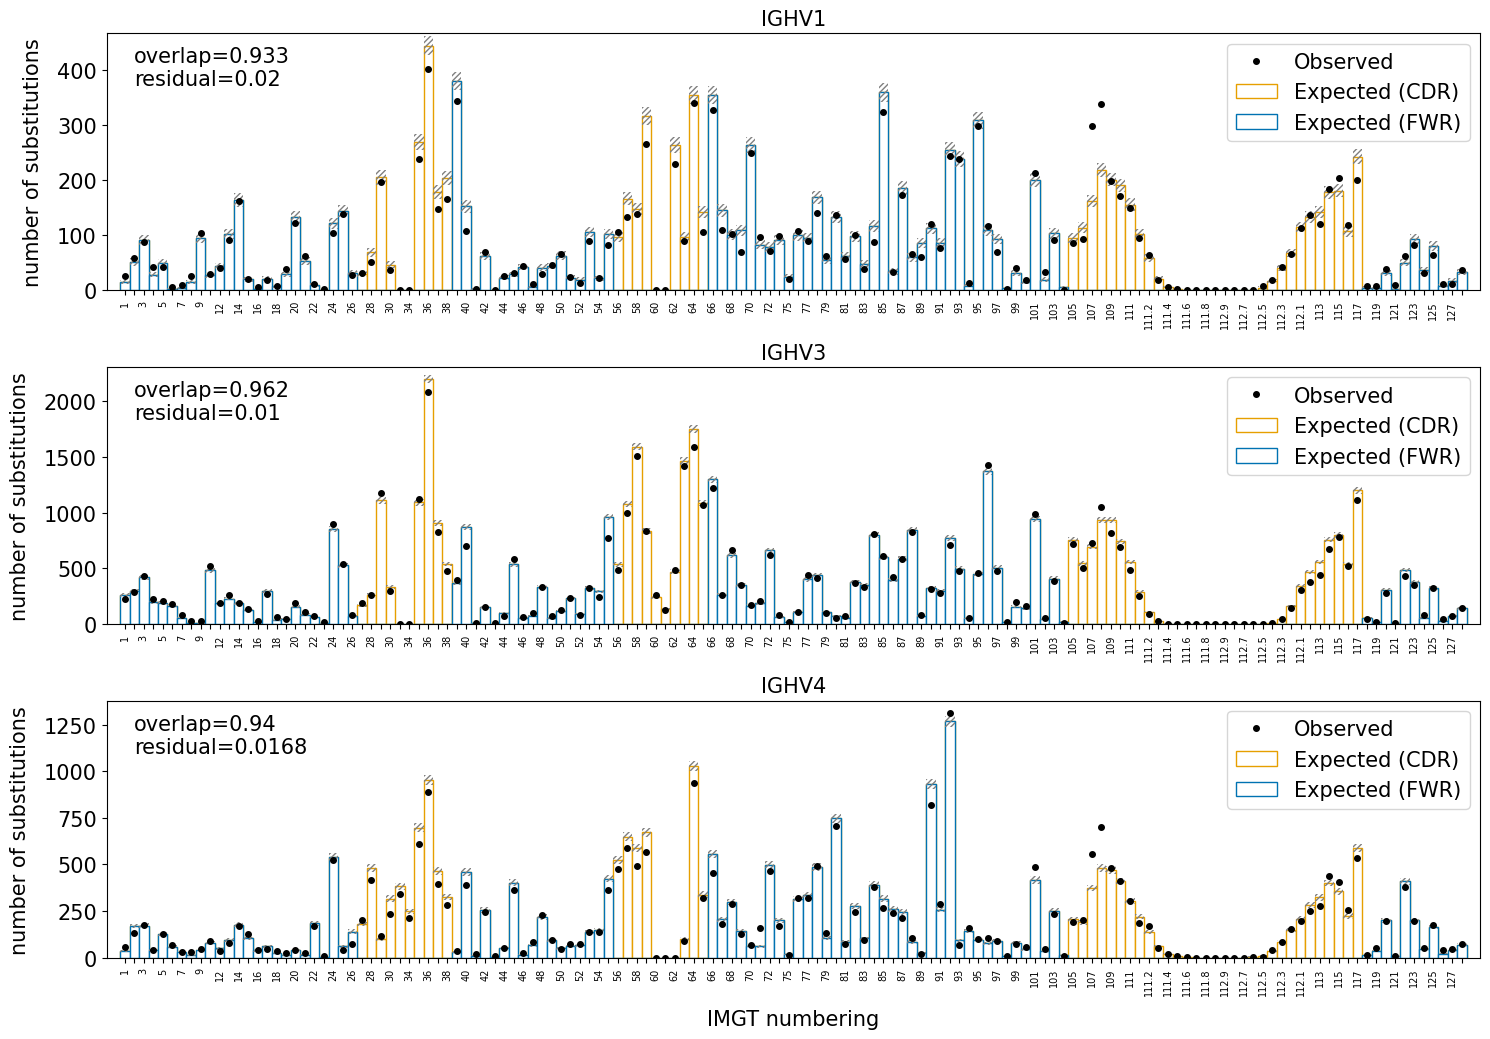

In [ ]:
dataset_name = "v1vanwinkleheavyTestnoN"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
    dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", "v1vanwinkleheavyTestnoN", f"{test_output_prefix}.branch_lengths_csv")

    # when trying to run this, I got an error about not being in the anarci dict. so I added the same entry as the 
    #     "v1vanwinkleheavyTestnoN": "DATA_DIR/anarci/vanwinkle-170-igh_anarci-seqs_imgt_H_patch.csv", is this okay??
complete_plotter, plotter_dict = write_sites_oe(
    crepe_prefix=crepe_prefix,
    dataset_name=dataset_name,
    #branch_length_path=f"/fh/fast/matsen_e/wdumm/for_noam/dnsm_1m-v1jaffe+v1tang-joint_ON_v1vanwinkleheavyTest_branch_lengths_csv",
    branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
    csv_output_path=f"{test_output_prefix}-sites-oe.csv",
    v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
    fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
    min_log_prob=-4,
    replace_title=True,
)
complete_plotter = complete_plotter["h"]

### Comparing selection factors and mutation frequencies between V3 and V4

In [ ]:

def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
    site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
    site_counts = site_sub_probs_df["site"].value_counts()
    cutoff = site_counts.quantile(quantile_cutoff)
    sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
    site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
    return site_sub_probs_df

def sort_df_by_site(df):
    sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
    return df.iloc[sorted_index]

def build_persite_df(site_sub_probs_df):
    persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
        mean_prob=('prob', 'mean'),
        mean_neutral_prob=('neutral_prob', 'mean'),
        mean_selection_factor=('selection_factor', 'mean'),
        mut_freq=('mutation', 'mean')
    ).reset_index()

    persite_df = sort_df_by_site(persite_df)

    return persite_df


# Assign plotters for all seven IGHV families
plotterV1 = plotter_dict["IGHV1h"]
plotterV2 = plotter_dict["IGHV2h"]
plotterV3 = plotter_dict["IGHV3h"]
plotterV4 = plotter_dict["IGHV4h"]
plotterV5 = plotter_dict["IGHV5h"]
plotterV6 = plotter_dict["IGHV6h"]
plotterV7 = plotter_dict["IGHV7h"]

# First, build persite dataframes for all seven IGHV families
# this can be used to get sites in common that are present in at least 0.05 of each family
persiteV1 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV1))
persiteV2 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV2))
persiteV3 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV3))
persiteV4 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV4))
persiteV5 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV5))
persiteV6 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV6))
persiteV7 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV7))

# Create a list of all persite dataframes that are not None
persite_dfs = []
for i in range(1, 8):
    var_name = f"persiteV{i}"
    if globals()[var_name] is not None and len(globals()[var_name]) > 0:
        persite_dfs.append(globals()[var_name])

# Find common sites across all non-empty dataframes
if persite_dfs:
    common_sites = set(persite_dfs[0]["site"])
    for df in persite_dfs[1:]:
        common_sites &= set(df["site"])
    
    print(f"Found {len(common_sites)} common sites across available V families")
else:
    common_sites = set()
    print("No valid persite dataframes found")

# Restrict each persite dataframe to common sites
for i in range(1, 8):
    var_name = f"persiteV{i}"
    var_name_common = f"persiteV{i}_common"
    
    if globals()[var_name] is not None and len(globals()[var_name]) > 0:
        globals()[var_name_common] = globals()[var_name][globals()[var_name]["site"].isin(common_sites)]
        print(f"{var_name_common}: {len(globals()[var_name_common])} rows")
    else:
        globals()[var_name_common] = None
        print(f"{var_name_common} is None (source dataframe was empty)")



for plotter in plotter_dict.values():
    for colname in ["neutral_prob", "selection_factor", "prob"]:
        plotter.site_sub_probs_df[colname] = plotter.site_sub_probs_df[colname].apply(lambda it: it.item())
for colname in ["neutral_prob", "selection_factor", "prob"]:
    complete_plotter.site_sub_probs_df[colname] = complete_plotter.site_sub_probs_df[colname].apply(lambda it: it.item())


    complete_plotter.mut_obs_pred_df


In [ ]:
# add j gene data
vanwinkle_j_df = load_pcp_df('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_no-naive_addJ.csv.gz')
complete_plotter.pcp_df = pd.merge(complete_plotter.pcp_df, vanwinkle_j_df.rename(columns={'parent_h':'parent', 'child_h':'child'})[['parent', 'child', 'j_gene', 'v_gene_h']], on=['orig_pcp_idx', 'parent', 'child'], how='left')
